# Исследование регуляризаций

## Инициализация окружения

In [1]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from regression import R_square
from scipy.optimize import minimize_scalar
import numpy as np
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
X = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])

Y = np.array([
    1,
    5,
    2
])

N = 3

### Визуализация

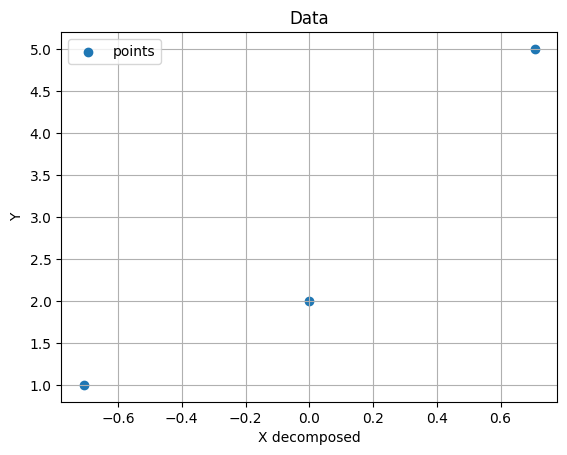

In [3]:
x_decomp = PCA(n_components=1).fit_transform(X)

fig, axis = plt.subplots()

axis.scatter(x_decomp, Y, label="points")

axis.set_title("Data")
axis.set_ylabel("Y")
axis.set_xlabel("X decomposed")
axis.grid(True)
axis.legend()
plt.show()

## Обучение моделей
### Без регуляризации

In [4]:
REGRESSION = LinearRegression(fit_intercept=False).fit(X, Y)
REGRESSION.coef_

array([-0.33333333,  3.66666667])

#### Проверка модели

In [5]:
R_SQUARE_REGRESSION = R_square(Y, REGRESSION.predict(X))
R_SQUARE_REGRESSION

np.float64(0.38461538461538464)

In [6]:
def CVSS(X, Y, model):
    cvss = []

    for i in range(N):
        y_test = Y[i]
        x_test = X[i]

        y_train = np.concat((Y[:i], Y[i+1:]))
        x_train = np.concat((X[:i], X[i+1:]))

        cross_regression = model.fit(x_train, y_train)
        cvss.append((y_test - cross_regression.predict([x_test])) ** 2)


    return np.sum(np.array(cvss))


In [7]:
R_SQUARE_CV_REGRESSION = CVSS(X, Y, LinearRegression(fit_intercept=False))
R_SQUARE_CV_REGRESSION

np.float64(48.0)

### Ridge

In [8]:
# alpha borders
left, right = 0, 10

In [9]:
import tqdm


def ridge_dependence(alpha):
    cvss = []
    for a in tqdm.tqdm(alpha):
        cvss.append(CVSS(X, Y, Ridge(fit_intercept=False, alpha=a)))
    return np.array(cvss)

100%|██████████| 150/150 [00:00<00:00, 173.31it/s]


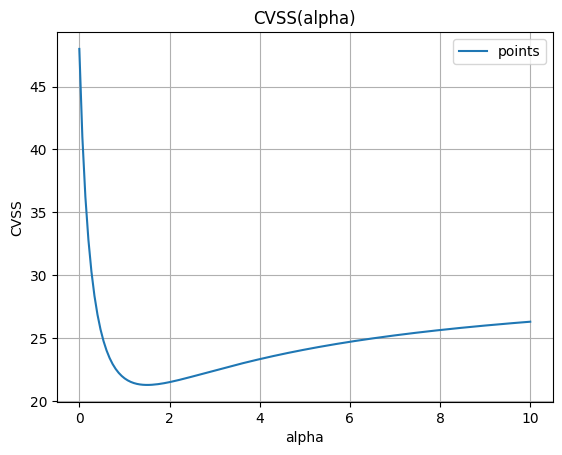

In [ ]:
fig, axis = plt.subplots()

axis.plot(np.linspace(left, right, 150), ridge_dependence(np.linspace(left, right, 150)), label="cvss")

axis.set_title("CVSS(alpha)")
axis.set_ylabel("CVSS")
axis.set_xlabel("alpha")
axis.grid(True)
axis.legend()
plt.show()

In [11]:
def objective_function(a):
    return CVSS(X, Y, Ridge(fit_intercept=False, alpha=a))


opt_result = minimize_scalar(objective_function, bounds=(left, right))
opt_result

 message: Solution found.
 success: True
  status: 0
     fun: 21.265056237970857
       x: 1.5056862352554576
     nit: 14
    nfev: 14

In [12]:
RIDGE = Ridge(fit_intercept=False, alpha=opt_result.x).fit(X, Y)
RIDGE.coef_

array([0.31152434, 1.90789341])

### Lasso

100%|██████████| 150/150 [00:00<00:00, 274.95it/s]


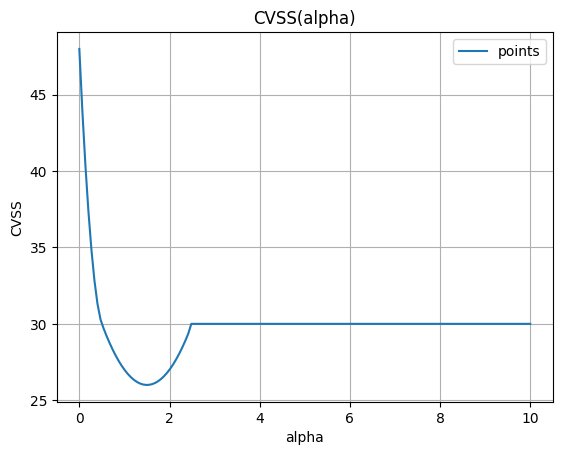

In [ ]:
def lasso_dependence(alpha):
    cvss = []
    for a in tqdm.tqdm(alpha):
        cvss.append(CVSS(X, Y, Lasso(fit_intercept=False, alpha=a)))
    return np.array(cvss)


fig, axis = plt.subplots()

# it works poorly near 0
axis.plot(np.linspace(left + 1e-8, right, 150), lasso_dependence(np.linspace(left + 1e-8, right, 150)), label="cvss")

axis.set_title("CVSS(alpha)")
axis.set_ylabel("CVSS")
axis.set_xlabel("alpha")
axis.grid(True)
axis.legend()
plt.show()

In [39]:
def objective_function(a):
    return CVSS(X, Y, Lasso(fit_intercept=False, alpha=a))


opt_result = minimize_scalar(objective_function, bounds=(left, 4))
opt_result

 message: Solution found.
 success: True
  status: 0
     fun: 26.0
       x: 1.5000000000000027
     nit: 7
    nfev: 7

In [35]:
LASSO = Lasso(fit_intercept=False, alpha=opt_result.x).fit(X, Y)
LASSO.coef_

array([0.  , 1.25])